In [2]:
import networkx as nx
import random
from dataclasses import dataclass
from typing import Dict, Optional, List
import numpy as np
import matplotlib.pyplot as plt
from networkx.drawing.nx_agraph import graphviz_layout
from tribal import BaseTree
from tribal.expansion_graph import ConstructGraph, ConstructGraphMulti
from tribal.lineage_tree import MPTR as MPTR_original
from tribal.mptr_cp_gur import MPTR_CP_GUR
from itertools import combinations
import pyomo.environ as pyo
from benchmark.simulate_tree import random_rooted_binary_tree, make_reversible_character, make_irreversible_character, make_tree_character, simulate_on_tree, contract_tree_by_characters, construct_expansion_graph

In [ ]:
# CHARACTER EXAMPLES:
# Character types: irreversible, reversible, dag, tree

rng = np.random.default_rng(123)

isotype = make_irreversible_character(
    name="isotype",
    n_states=6,
    alpha=1.0,
    self_bias=1.0,
    preserve_triangle=True
)

functional_state = make_reversible_character(
    name="functional_state",
    n_states=8,
    alpha=0.8,
    preserve_triangle=True
)

third_property = make_reversible_character(
    name="third_property",
    n_states=3,
    alpha=0.8,
)

tree_char = make_tree_character(
    name="tree_character",
    n_states=6,
    alpha=1,
    self_bias=1,
    closure_prob=0.5,
    preserve_triangle=True,
    max_iters=100
)

In [5]:
# Create set of characters to use in simulation:

characters = {"isotype": isotype, "functional_state": functional_state, "tree_character": tree_char}

In [6]:
# Simulate the tree:

n_leaves = 6
tree, root = random_rooted_binary_tree(n_leaves, seed=None)

tree,states = simulate_on_tree(tree, root, characters, rng=rng)

labels = {
    node: f"{node}_({','.join(str(v) for v in data.values())})"
    for node, data in states.items()
}

In [ ]:
#For visualizations (do not modify)

def name_node(node, labels,  is_poly=False, is_leaf=False):
        lab = str(node)

        for l in labels:
            lab = lab + "_" + str(l)

        if is_poly:
             lab += "_p"
        return  lab

def draw_tree(tree,i,labels=None):
    pos = graphviz_layout(tree,prog='dot',args=f"-Grankdir-TB")
    if labels==None:
        nx.draw(tree,pos,with_labels=True,node_size=500,font_size=8,arrows=True,arrowstyle="->",arrowsize=10,ax=axes[i],node_color='lightblue')
    else:
        nx.draw(tree,pos,with_labels=True,labels=labels,node_size=500,font_size=8,arrows=True,arrowstyle="->",arrowsize=10,ax=axes[i],node_color='lightblue')

In [8]:
# Example: Contract the isotype and tree_character:

contracted_tree, contracted_states, contracted_characters = contract_tree_by_characters(
   tree,
   states, characters,
   chars_to_contract=["isotype","tree_character"])


contracted_labels = {
   node: f"{node}_({','.join(str(v) for v in data.values())})"
   for node, data in contracted_states.items()
}


expansion_graph = construct_expansion_graph(contracted_tree,contracted_states,contracted_characters,root)


In [11]:
def draw_tree(tree,i,labels=None):
    pos = graphviz_layout(tree,prog='dot',args=f"-Grankdir-TB")
    if labels==None:
        nx.draw(tree,pos,with_labels=False,node_size=1000,font_size=8,arrows=True,arrowstyle="->",arrowsize=10,ax=axes[i],node_color='lightblue')
    else:
        nx.draw(tree,pos,with_labels=True,labels=labels,node_size=1000,font_size=8,arrows=True,arrowstyle="->",arrowsize=10,ax=axes[i],node_color='lightblue')

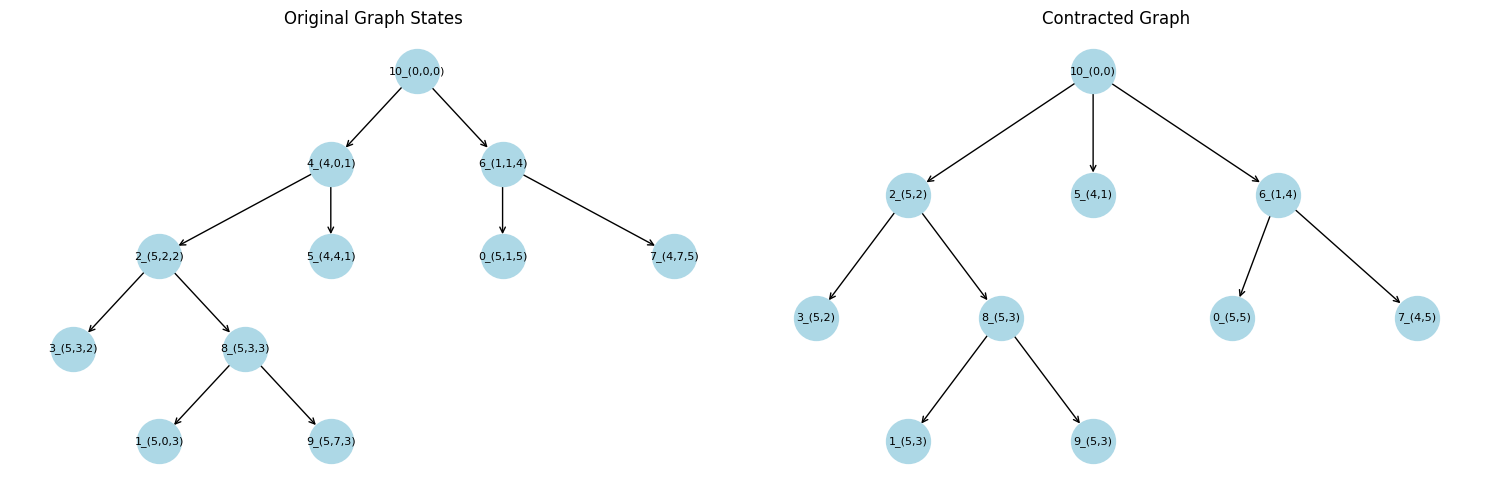

In [ ]:
# Visualize the original graph with all three characters, and the contracted graph:

fig,axes = plt.subplots(1, 2, figsize=(15,5))

draw_tree(tree,0, labels)
axes[0].set_title("Original Graph States")

draw_tree(contracted_tree,1,contracted_labels)
axes[1].set_title("Contracted Graph")

plt.tight_layout()
plt.show()

In [ ]:
# Set up the tree and expansion graph for the ILPs

base_tree = BaseTree(contracted_tree, root=root, id=0, name="contracted_test")

cg = ConstructGraphMulti(contracted_states, contracted_characters, root_identifier=root)
fg = cg.build(base_tree)

In [ ]:
# Multi-commodity flow (MCF) ILP

mptr = MPTR_original(
    fg.G,
    base_tree.T,
    fg.find_terminals(),
    fg.iso_weights,
    fg.tree_to_graph,
    root=root,
)
score_m, tree_m = mptr.run()
print(f"MPTR objective = {score_m:.4f}")

MPTR objective = 11.3425


In [ ]:
# Cutting planes ILP (using Gurobi)

mptr_cp_g = MPTR_CP_GUR(
    fg.G,
    base_tree.T,
    fg.find_terminals(),
    fg.iso_weights,
    fg.tree_to_graph,
    root=root,
)
score_cp, tree_cp = mptr_cp_g.run()
print(f"MPTR objective = {score_cp:.4f}")

Restricted license - for non-production use only - expires 2027-11-29


MPTR objective = 11.3425


C:\Users\davisoc\AppData\Local\Temp\ipykernel_4196\3075795450.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


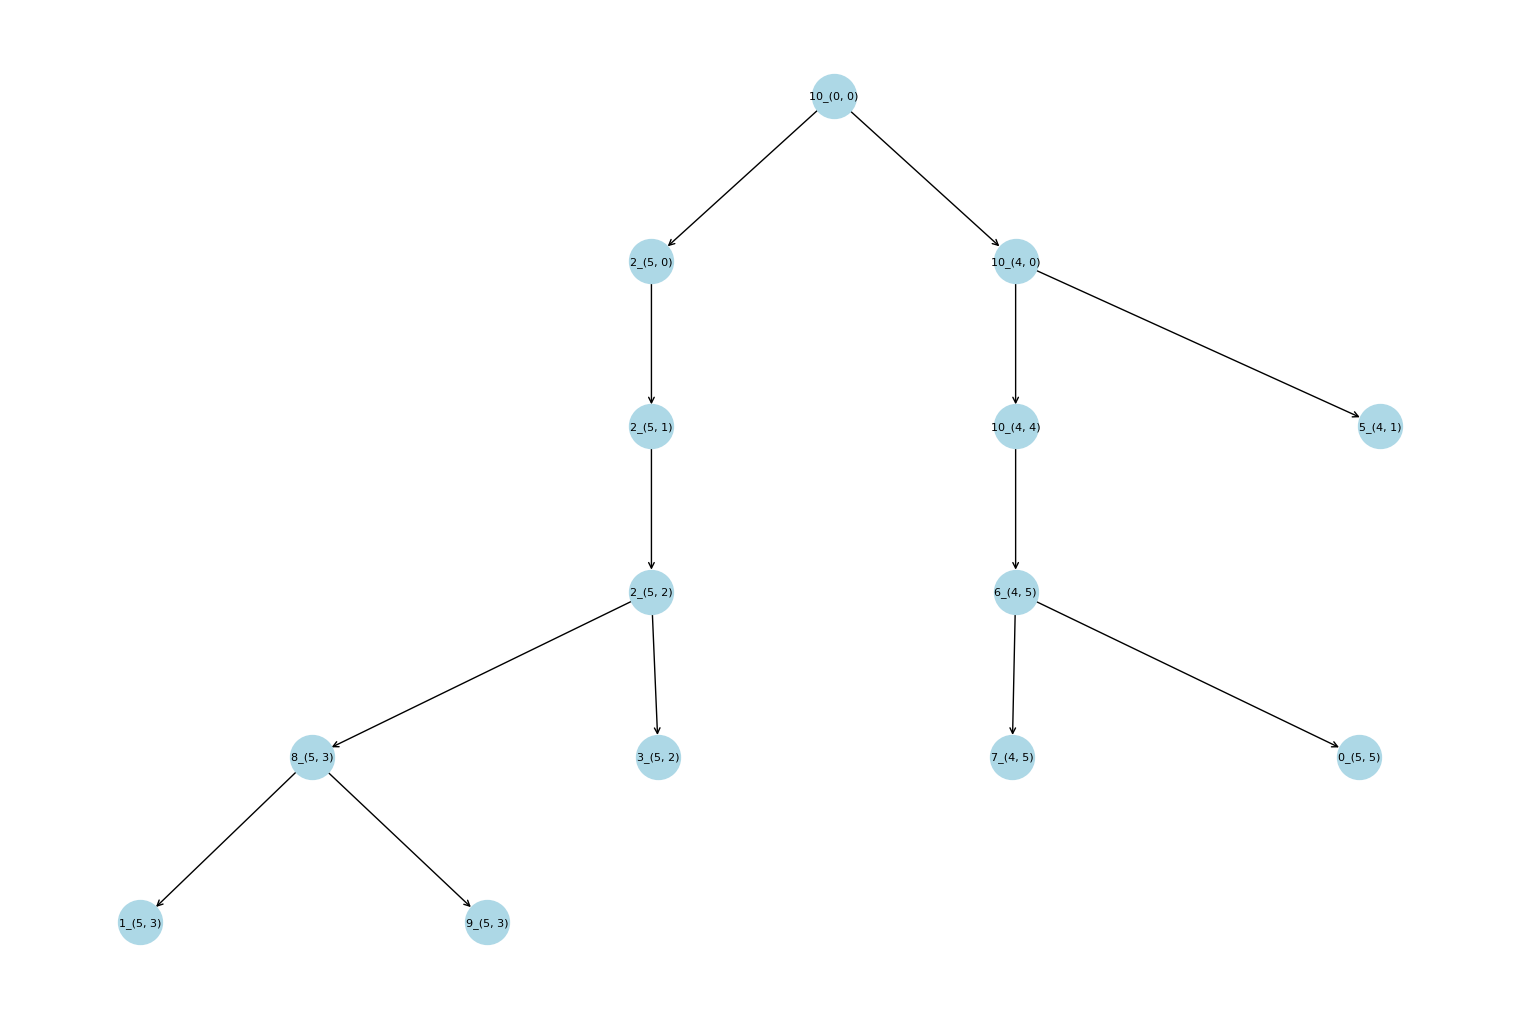

In [ ]:
# Visualize the resulting tree of the MCF ILP (both ILPs will have the same tree output)

plt.figure(figsize=(15,10))

pos = graphviz_layout(tree_m,prog='dot',args=f"-Grankdir-TB")
nx.draw(tree_m,pos,with_labels=True,node_size=1000,font_size=8,arrows=True,arrowstyle="->",arrowsize=10,node_color='lightblue')

plt.tight_layout()
plt.show()